# **Modeling ML**

Este notebook estuda a previsão de `inflation_target` com modelos de machine learning, usando variáveis teóricas em nível, lags selecionados e diferentes combinações dessas variáveis. A comparação entre modelos é feita com métricas de erro e análise de overfitting no treino e no teste.


In [1]:
# ! pip install lightgbm

In [2]:
# ! pip install optuna 
# Optuna is a hyperparameter optimization framework that automates the process of finding the best hyperparameters for machine learning models.

In [3]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import optuna
import pipeline_datapreparation as DataPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 322
np.random.seed(RANDOM_STATE)

---

## **Configurações**

### **Obtenção dos dados**
Os conjuntos de treino e teste já estão divididos previamente. Ambos passam pela mesma *pipeline* com seleção de variáveis, tratamento de outliers e criação dos lags selecionados.

In [4]:
df_train = DataPipeline.prepare_dataset(
    "dados/train.csv",
    select_features=True,
    stationary=False,
    treat_outliers=True,
    create_lags=True,
)["prepared_data"]

df_test = DataPipeline.prepare_dataset(
    "dados/test.csv",
    select_features=True,
    stationary=False,
    treat_outliers=True,
    create_lags=True,
)["prepared_data"].loc["2023-07-01":]

TARGET_COL = DataPipeline.TARGET_COL

THEORETICAL_VARIABLES = [
     "epu_pt_epu",
     "ULCIN_PT_ea-qd",
     "EXPGS_PT_ea-qd",
     "IMPGS_PT_ea-qd",
     "CCI_PT_ea-md",
     "GDP_PT_ea-qd",
     "UNETOT_PT_ea-md",
     "PPIPT_ppi",
]

print("Conjunto de Treino")
display(df_train.head())

print("Conjunto de Teste")
display(df_test.head())

print(f"Shape conjunto de treino: {df_train.shape}")
print(f"Shape conjunto de teste: {df_test.shape}")

Conjunto de Treino


,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292769,-1.333886,2.651460,1.612561,-1.857311,2.370485,-2.090914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-1.652773,-1.239516,1.555927,-1.236718,-1.348727,2.718651,1.557800,-1.854323,2.425870,-2.082324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.1,NaN,NaN
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,-1.466960,NaN,NaN,NaN,NaN,NaN,NaN,1.8,2.1,NaN
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-1.118196,-1.466960,NaN,NaN,NaN,NaN,NaN,1.5,1.8,2.1
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-0.958600,-1.118196,-1.46696,NaN,NaN,NaN,NaN,2.1,1.5,1.8


Conjunto de Teste


,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-01,2.386643,-0.948811,-0.212584,2.307421,2.135289,1.011992,-0.075929,2.574181,1.955093,2.146303,...,0.775336,1.009704,0.798917,1.009527,0.981243,0.960468,2.373517,3.4,4.0,5.7
2023-08-01,2.417567,-0.948811,-0.289823,2.324309,2.090561,1.126217,-0.176325,2.599608,1.955093,2.224553,...,0.666480,0.775336,1.009704,0.798917,1.009527,0.981243,2.153891,3.1,3.4,4.0
2023-09-01,2.455818,-0.890670,-0.507197,2.351462,2.066858,1.247161,-0.577912,2.645049,1.993863,2.160515,...,0.837010,0.666480,0.775336,1.009704,0.798917,1.009527,1.915145,3.7,3.1,3.4
2023-10-01,2.461355,-0.890670,-0.693885,2.381320,2.077965,1.435297,-0.687436,2.729573,1.982785,2.176974,...,1.336650,0.837010,0.666480,0.775336,1.009704,0.798917,1.980482,3.6,3.7,3.1
2023-11-01,2.462122,-0.919741,-0.761598,2.408523,2.113032,1.247161,-0.961245,2.831292,1.905246,2.152486,...,1.848272,1.336650,0.837010,0.666480,0.775336,1.009704,1.750668,2.1,3.6,3.7


Shape conjunto de treino: (282, 86)
Shape conjunto de teste: (28, 86)


In [5]:
import importlib
import pipeline_datapreparation as p

importlib.reload(p)
print(p.__file__)


C:\Users\josev\Documents\Iscte - Instituto Universitário de Lisboa\Ano 3\Segundo Semestre\Projeto Final Aplicado em Ciência de Dados\Parte Técnica\Inflation-Forecast-Using-Machine-Learning-Models\pipeline_datapreparation.py


### **Modelos**

Modelos avaliados: **`Ridge`**, **`Random Forest`** e **`LGBMRegressor`**.

In [6]:
models = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "RF - MSE": RandomForestRegressor(
        criterion='squared_error',
        random_state=RANDOM_STATE,
    ),
    "RF - MAE": RandomForestRegressor(
        criterion='absolute_error',
        random_state=RANDOM_STATE,
    ),
    "LGBMRegressor": LGBMRegressor(        
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

### **Avaliação**

As métricas calculadas são **`RMSE`** e **`MAE`** em valor absoluto, e **`WAPE (%)`** em percentagem. Para verificar *overfitting*, compara-se o erro de teste com o erro de treino e considera-se que existe *overfitting* quando essa diferença percentual ultrapassa **15%** em pelo menos uma das métricas.

In [7]:
OVERFITTING_THRESHOLD_PCT = 15.0

def relative_error_increase_pct(train_metric, test_metric):
    if pd.isna(train_metric) or train_metric == 0:
        return np.nan
    return round(((test_metric - train_metric) / train_metric) * 100, 3)

def has_overfitting(train_metrics, test_metrics, threshold_pct=OVERFITTING_THRESHOLD_PCT):
    metric_increases = [
        relative_error_increase_pct(train_metric, test_metric)
        for train_metric, test_metric in zip(train_metrics, test_metrics)
    ]
    return any(pd.notna(increase) and increase > threshold_pct for increase in metric_increases)

def regression_metrics(y_true, y_pred):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 2)
    mae = round(mean_absolute_error(y_true, y_pred), 2)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
    return (
        rmse,
        mae,
        round(wape, 5) if not np.isnan(wape) else np.nan,
    )

metric_cols = ["rmse", "mae", "wape"]

colors = {"Treino": "#8E9091", "Teste": "#3634bc"}

### **Ranking Models**

In [8]:
def rank_models_by_average_test_rank(performance_df):
    ranked_df = performance_df.copy()

    ranked_df["rank_test_rmse"] = ranked_df["test_rmse"].rank(
        method="average", # empates recebem a média dos ranks possíveis
        ascending=True,
    )

    ranked_df["rank_test_mae"] = ranked_df["test_mae"].rank(
        method="average",
        ascending=True,
    )

    ranked_df["rank_test_wape"] = ranked_df["test_wape"].rank(
        method="average",
        ascending=True,
    )

    ranked_df["Overfitting?"] = ranked_df.apply(
        lambda row: has_overfitting(
            [row["train_rmse"], row["train_mae"], row["train_wape"]],
            [row["test_rmse"], row["test_mae"], row["test_wape"]],
        ),
        axis=1,
    )

    ranked_df["rank_medio"] = ranked_df[
        ["rank_test_rmse", "rank_test_mae", "rank_test_wape"]
    ].mean(axis=1)

    ranked_df = (
        ranked_df
        .sort_values(["rank_medio"])
        .reset_index(drop=True)
    )

    return ranked_df


---

## **Modelação com o desfasamento da variável alvo**

Nesta seção avalia-se um modelo base usando apenas `inflation_target` e o seu primeiro lag (`inflation_target_lag_1`). O objetivo é servir de referência para comparar o desempenho dos modelos com variáveis teóricas, em nível e com lags.

A comparação entre treino e teste é feita com `RMSE`, `MAE` e `WAPE (%)`. Considera-se *overfitting* quando o erro de teste ultrapassa em mais de `15%` o erro de treino em pelo menos uma destas métricas.



In [9]:
# target_lag_col = f"{TARGET_COL}_lag_1"
target_lag_col = [f"{TARGET_COL}_lag_{i}" for i in range(1, 4)]


# train_lag_df = df_train[[TARGET_COL, target_lag_col]].dropna().copy()
# test_lag_df = df_test[[TARGET_COL, target_lag_col]].dropna().copy()

train_lag_df = df_train[[TARGET_COL] + target_lag_col].dropna().copy()
test_lag_df = df_test[[TARGET_COL] + target_lag_col].copy()


# Ajustamento das datas de treino e teste para garantir que não haja sobreposição de datas
common_dates = train_lag_df.index.intersection(test_lag_df.index)
test_lag_df = test_lag_df.drop(index=common_dates)

X_train = train_lag_df[target_lag_col]
y_train = train_lag_df[TARGET_COL]

X_test = test_lag_df[target_lag_col]
y_test = test_lag_df[TARGET_COL]

print(f"Train: {X_train.index.min().date()} -> {X_train.index.max().date()} | {len(X_train)} obs")
print(f"Test:  {X_test.index.min().date()} -> {X_test.index.max().date()} | {len(X_test)} obs")


Train: 2000-04-01 -> 2023-06-01 | 279 obs
Test:  2023-07-01 -> 2025-10-01 | 28 obs


In [10]:
X_train

,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,
2000-04-01,1.5,1.8,2.1
2000-05-01,2.1,1.5,1.8
2000-06-01,2.5,2.1,1.5
2000-07-01,2.9,2.5,2.1
2000-08-01,3.3,2.9,2.5
...,...,...,...
2023-02-01,8.4,9.6,9.9
2023-03-01,8.2,8.4,9.6
2023-04-01,7.4,8.2,8.4


In [11]:
results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
    test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

    results.append({
        "model": model_name,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_wape": train_wape,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_wape": test_wape,
        "relative_error_increase_pct_rmse": relative_error_increase_pct(train_rmse, test_rmse),
        "relative_error_increase_pct_mae": relative_error_increase_pct(train_mae, test_mae),
        "relative_error_increase_pct_wape": relative_error_increase_pct(train_wape, test_wape),
        "Overfitting?": has_overfitting(
            [train_rmse, train_mae, train_wape],
            [test_rmse, test_mae, test_wape],
        ),
    })

    predictions[model_name] = pd.DataFrame(
        {"y_true": y_test, "y_pred": y_pred_test},
        index=y_test.index,
    )

metrics_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
metrics_df = rank_models_by_average_test_rank(metrics_df)
display(metrics_df)


,model,train_rmse,train_mae,train_wape,test_rmse,test_mae,test_wape,relative_error_increase_pct_rmse,relative_error_increase_pct_mae,relative_error_increase_pct_wape,Overfitting?,rank_test_rmse,rank_test_mae,rank_test_wape,rank_medio
0,RF - MAE,0.21,0.15,0.06506,0.48,0.33,0.13693,128.571,120.000,110.467,True,1.0,1.0,1.0,1.0
1,RF - MSE,0.20,0.14,0.06209,0.50,0.35,0.14265,150.000,150.000,129.747,True,2.0,2.0,2.0,2.0
2,Ridge,0.39,0.30,0.13147,0.51,0.38,0.15565,30.769,26.667,18.392,True,3.0,3.0,3.0,3.0
3,LGBMRegressor,0.63,0.36,0.15863,0.52,0.39,0.16169,-17.460,8.333,1.929,False,4.0,4.0,4.0,4.0


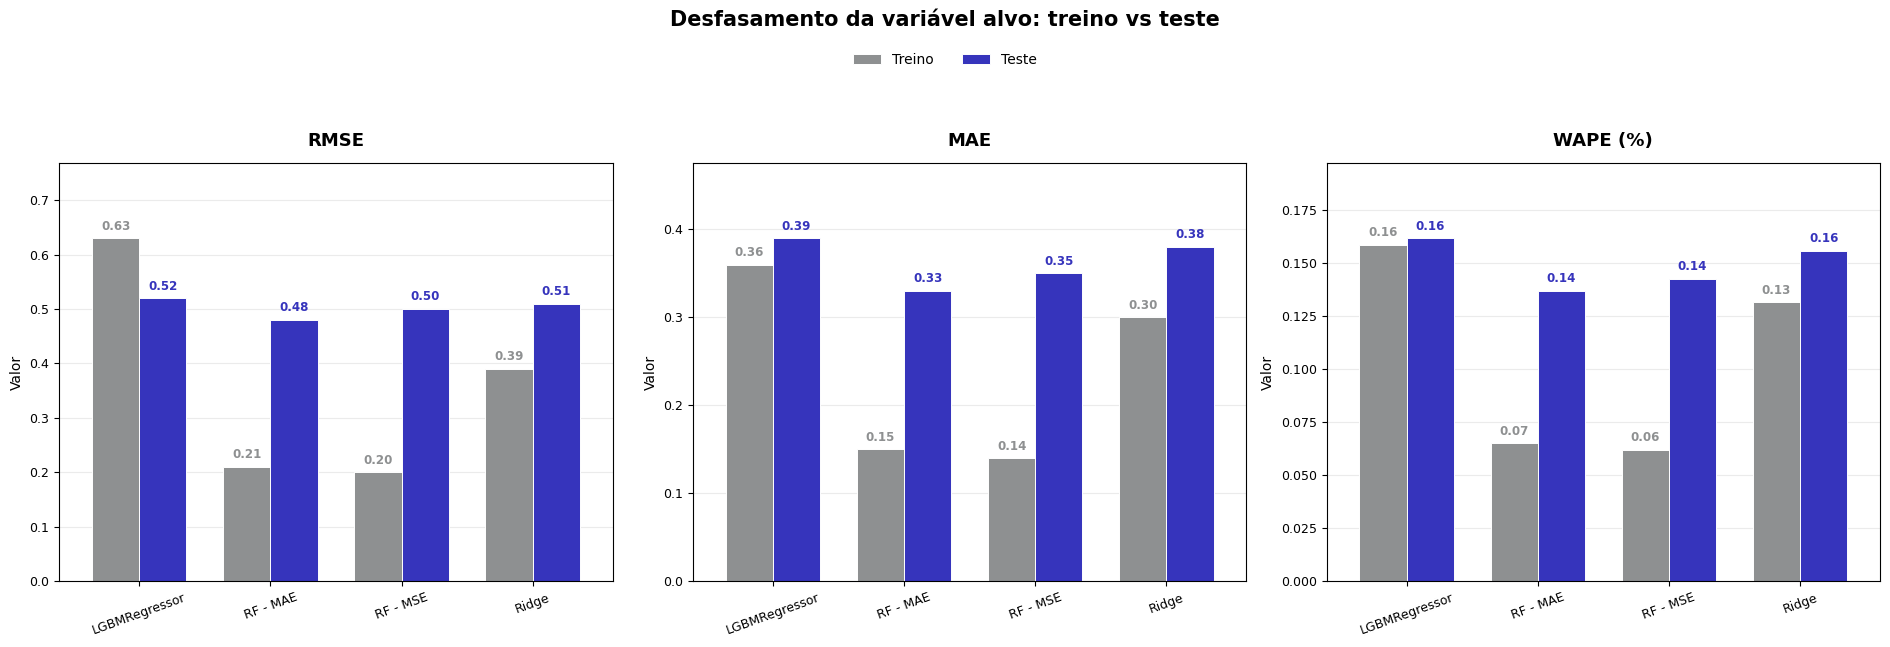

In [12]:
theoretical_plot_data = []
metric_display = {"rmse": "RMSE", "mae": "MAE", "wape": "WAPE (%)"}

for _, row in metrics_df.iterrows():
    for metric in metric_cols:
        theoretical_plot_data.append({
            "model": row["model"],
            "metric": metric_display[metric],
            "dataset": "Treino",
            "value": row[f"train_{metric}"],
        })

        theoretical_plot_data.append({
            "model": row["model"],
            "metric": metric_display[metric],
            "dataset": "Teste",
            "value": row[f"test_{metric}"],
        })


theoretical_plot_df = pd.DataFrame(theoretical_plot_data)

fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharex=False)

metrics_order = ["RMSE", "MAE", "WAPE (%)"]

for ax, metric in zip(axes, metrics_order):
    metric_df = theoretical_plot_df[theoretical_plot_df["metric"] == metric]
    pivot_df = metric_df.pivot(index="model", columns="dataset", values="value")
    pivot_df = pivot_df[["Treino", "Teste"]]

    pivot_df.plot(
        kind="bar",
        ax=ax,
        color=[colors["Treino"], colors["Teste"]],
        width=0.72,
        edgecolor="white",
        linewidth=0.7,
    )

    ymax = pivot_df.max().max()
    ax.set_ylim(0, ymax * 1.22)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Valor", fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            bar_color = bar.get_facecolor()
            ax.annotate(
                f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                color=bar_color,
            )

    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Desfasamento da variável alvo: treino vs teste",
    fontsize=15,
    fontweight="bold",
    y=1.07,
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



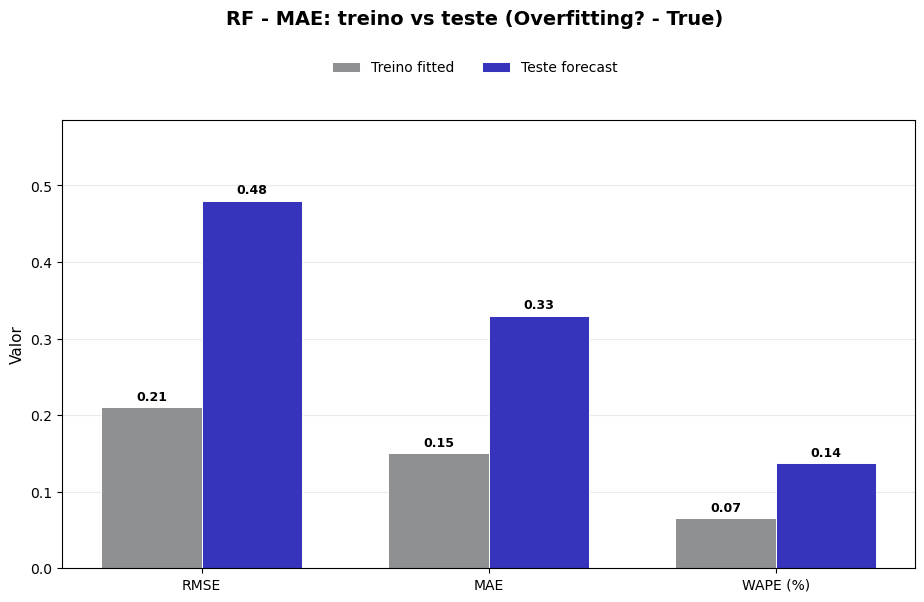

In [13]:
def plot_top_model_metrics(metrics_df, top_n=1):
    top_models = metrics_df.sort_values("test_rmse").head(top_n).copy()

    metric_labels = ["RMSE", "MAE", "WAPE (%)"]
    train_cols = ["train_rmse", "train_mae", "train_wape"]
    test_cols = ["test_rmse", "test_mae", "test_wape"]

    for _, row in top_models.iterrows():
        model_name = row["model"]
        overfitting_col = "Overfitting?" if "Overfitting?" in row.index else "overfitting?"
        overfitting = row[overfitting_col]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(11, 6.5))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="Treino fitted",
            color=colors["Treino"],
            edgecolor="white",
            linewidth=0.7,
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="Teste forecast",
            color=colors["Teste"],
            edgecolor="white",
            linewidth=0.7,
        )

        ymax = max(max(train_values), max(test_values))
        ax.set_ylim(0, ymax * 1.22)

        fig.suptitle(
            f"{model_name}: treino vs teste (Overfitting? - {overfitting})",
            fontsize=14,
            fontweight="bold",
            y=0.97,
        )

        fig.legend(
            handles=[bars_train, bars_test],
            labels=["Treino fitted", "Teste forecast"],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.91),
            ncol=2,
            frameon=False,
        )

        ax.set_ylabel("Valor", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bars in [bars_train, bars_test]:
            labels = [f"{bar.get_height():.2f}" for bar in bars]
            ax.bar_label(
                bars,
                labels=labels,
                padding=3,
                fontsize=9,
                fontweight="bold",
            )

        fig.subplots_adjust(top=0.80)
        plt.show()


plot_top_model_metrics(metrics_df, top_n=1)



---

## **Modelos com variáveis teóricas em nível**

Nesta secção usam-se apenas as variáveis teóricas selecionadas, em nível. A `pipeline` é aplicada para preparar os dados e tratar os *outliers*, sem criação de lags. Os modelos são comparados com `RMSE`, `MAE` e `WAPE`, avaliando o desempenho em treino e teste.


In [14]:
from sklearn.base import clone

level_cols = [TARGET_COL] + THEORETICAL_VARIABLES

train_levels = df_train[level_cols].dropna().copy()
test_levels = df_test[level_cols].dropna().copy()

# Ajustamento das datas de treino e teste para garantir que não haja sobreposição de datas
common_dates = train_levels.index.intersection(test_levels.index)
test_levels = test_levels.drop(index=common_dates)

X_train = train_levels[THEORETICAL_VARIABLES]
y_train = train_levels[TARGET_COL]

X_test = test_levels[THEORETICAL_VARIABLES]
y_test = test_levels[TARGET_COL]

print(f"Treino: {X_train.index.min().date()} -> {X_train.index.max().date()} | {len(X_train)} obs")
print(f"Teste:  {X_test.index.min().date()} -> {X_test.index.max().date()} | {len(X_test)} obs")


Treino: 2000-01-01 -> 2023-06-01 | 282 obs
Teste:  2023-07-01 -> 2025-10-01 | 28 obs


In [15]:
results = []
predictions = {}

for model_name, model in models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred_train = fitted_model.predict(X_train)
    y_pred_test = fitted_model.predict(X_test)

    train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
    test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

    results.append({
        "model": model_name,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_wape": train_wape,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_wape": test_wape,
        "Overfitting?": has_overfitting(
            [train_rmse, train_mae, train_wape],
            [test_rmse, test_mae, test_wape],
        ),
    })

    predictions[model_name] = pd.DataFrame(
        {"y_true": y_test, "y_pred": y_pred_test},
        index=y_test.index,
    )

theoretical_metrics_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
theoretical_metrics_df = rank_models_by_average_test_rank(theoretical_metrics_df)
display(theoretical_metrics_df)


,model,train_rmse,train_mae,train_wape,test_rmse,test_mae,test_wape,Overfitting?,rank_test_rmse,rank_test_mae,rank_test_wape,rank_medio
0,Ridge,1.04,0.82,0.36703,1.18,0.96,0.39397,True,1.0,1.0,1.0,1.000000
1,RF - MSE,0.16,0.11,0.04761,2.06,1.98,0.81330,True,2.0,3.0,3.0,2.666667
2,RF - MAE,0.16,0.11,0.05020,2.21,1.80,0.74029,True,4.0,2.0,2.0,2.666667
3,LGBMRegressor,0.26,0.18,0.07900,2.13,2.02,0.83082,True,3.0,4.0,4.0,3.666667


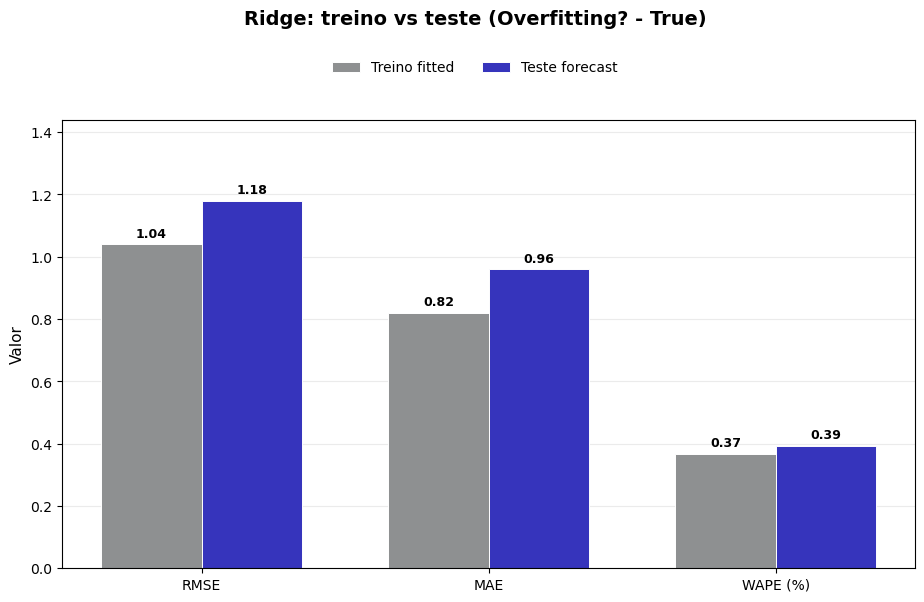

In [16]:
def plot_top_theoretical_model_metrics(theoretical_metrics_df, top_n=1):
    top_models = theoretical_metrics_df.sort_values("test_rmse").head(top_n).copy()

    metric_labels = ["RMSE", "MAE", "WAPE (%)"]
    train_cols = ["train_rmse", "train_mae", "train_wape"]
    test_cols = ["test_rmse", "test_mae", "test_wape"]

    for _, row in top_models.iterrows():
        model_name = row["model"]
        overfitting_col = "Overfitting?" if "Overfitting?" in row.index else "overfitting?"
        overfitting = row[overfitting_col]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(11, 6.5))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="Treino fitted",
            color=colors["Treino"],
            edgecolor="white",
            linewidth=0.7,
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="Teste forecast",
            color=colors["Teste"],
            edgecolor="white",
            linewidth=0.7,
        )

        ymax = max(max(train_values), max(test_values))
        ax.set_ylim(0, ymax * 1.22)

        fig.suptitle(
            f"{model_name}: treino vs teste (Overfitting? - {overfitting})",
            fontsize=14,
            fontweight="bold",
            y=0.97,
        )

        fig.legend(
            handles=[bars_train, bars_test],
            labels=["Treino fitted", "Teste forecast"],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.91),
            ncol=2,
            frameon=False,
        )

        ax.set_ylabel("Valor", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bars in [bars_train, bars_test]:
            labels = [f"{bar.get_height():.2f}" for bar in bars]
            ax.bar_label(
                bars,
                labels=labels,
                padding=3,
                fontsize=9,
                fontweight="bold",
            )

        fig.subplots_adjust(top=0.80)
        plt.show()


plot_top_theoretical_model_metrics(theoretical_metrics_df, top_n=1)



---

## **Modelos com variáveis teóricas em nível e os respetivos lags significativos**

Nesta fase usam-se as variáveis teóricas em nivel e, para cada uma, os respetivos lags na lista `SELECTED_LAGS`. A *pipeline* aplica o tratamento de outliers e cria os lags selecionados de forma gradual.

In [17]:
var_lags = {'GS1_fred-md': [10],
 'GS5_fred-md': [12],
 'OILPRICEx_fred-md_Eur': [1, 2, 3, 4, 5, 6, 7, 12],
 'CUSR0000SAC_fred-md': [1, 2, 11, 12],
 'PCEPI_fred-md': [12],
 'EMPENT_PT_ea-qd': [12],
 'REER42_PT_ea-md': [6, 7, 8, 9, 10, 11, 12],
 'HICPOV_PT_ea-md': [12],
 'HICPNEF_PT_ea-md': [12],
 'HICPSV_PT_ea-md': [12],
 'HICPNG_PT_ea-md': [1, 3, 4, 12],
 'DFGDP_PT_ea-qd': [12],
 'CCONFIX_PT_ea-md': [1, 2, 11, 12],
 'epu_pt_epu': [6, 7, 8],
 'GDP_PT_ea-qd': [1, 2, 3, 4, 5, 12],
 'ULCIN_PT_ea-qd': [12],
 'EXPGS_PT_ea-qd': [12],
 'IMPGS_PT_ea-qd': [2, 3],
 'CCI_PT_ea-md': [12],
 'UNETOT_PT_ea-md': [12],
 'PPIPT_ppi': [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]}

In [18]:
COMPUTACIONAL_VARIABLES = [
    'GS1_fred-md', 'GS5_fred-md', 'OILPRICEx_fred-md_Eur',
    'CUSR0000SAC_fred-md', 'PCEPI_fred-md', 'EMPENT_PT_ea-qd',
    'REER42_PT_ea-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
    'HICPSV_PT_ea-md', 'HICPNG_PT_ea-md', 'DFGDP_PT_ea-qd',
    'CCONFIX_PT_ea-md'
]

In [19]:
def build_lag_model(lag, models=models, include_target_lags=False, variables=THEORETICAL_VARIABLES):
    lags = list()
    for key, value in var_lags.items():
        if key in variables:
            for v in value:
                if v <= lag:
                    lags.append(f'{key}_lag_{v}')

    scores_train = {}
    scores_test = {}
    if include_target_lags:
        target_lags = ["inflation_target_lag_1"]

    # root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
    if include_target_lags:
        X_train = df_train[variables + lags + target_lags].dropna()
    else:
        X_train = df_train[variables + lags].dropna()
    y_train = df_train[TARGET_COL].iloc[lag:]
    
    if include_target_lags:
        X_test = df_test[variables + lags + target_lags]
    else:
        X_test = df_test[variables + lags]
    y_test = df_test[TARGET_COL]
    
    for model_name, clf in models.items():
        model_score_train = dict()
        model_score_test = dict()
        clf.fit(X_train, y_train)
    
        # Train set
        pred = clf.predict(X_train)
        model_score_train['rmse'], model_score_train['mae'], model_score_train['wape'] = regression_metrics(y_train, pred)
    
        # Test set
        pred = clf.predict(X_test)
        model_score_test['rmse'], model_score_test['mae'], model_score_test['wape'] = regression_metrics(y_test, pred)

        scores_train[model_name] = model_score_train
        scores_test[model_name] = model_score_test

    return X_test, scores_train, scores_test

In [20]:
def evaluate_lag_performance(
    variables,
    include_target_lags=False,
    lag_range=range(1, 13),
    models=models,
):
    lag_performance = {}

    for lag in lag_range:
        X_test, scores_train, scores_test = build_lag_model(
            lag=lag,
            models=models,
            include_target_lags=include_target_lags,
            variables=variables,
        )

        lag_performance[lag] = {
            "train": scores_train,
            "test": scores_test,
        }

    lag_performance_rows = []

    for lag, lag_results in lag_performance.items():
        for model_name in lag_results["train"].keys():
            row = {
                "lag": lag,
                "model": model_name,
                "train_rmse": lag_results["train"][model_name]["rmse"],
                "train_mae": lag_results["train"][model_name]["mae"],
                "train_wape": lag_results["train"][model_name]["wape"],
                "test_rmse": lag_results["test"][model_name]["rmse"],
                "test_mae": lag_results["test"][model_name]["mae"],
                "test_wape": lag_results["test"][model_name]["wape"],
            }
            lag_performance_rows.append(row)

    lag_performance_df = pd.DataFrame(lag_performance_rows)
    lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)

    return {
        "raw_results": lag_performance,
        "performance_df": lag_performance_df,
        "ranked_df": lag_performance_ranked_df,
    }



In [21]:
results_computacional = evaluate_lag_performance(
    variables=COMPUTACIONAL_VARIABLES,
    include_target_lags=True,
)

results_theoretical = evaluate_lag_performance(
    variables=THEORETICAL_VARIABLES,
    include_target_lags=False, # O melhor modelo com as variáveis teóricas não inclui lags da variável alvo
)


In [22]:
lag_performance_df_theoretical = results_theoretical["ranked_df"][0:5]
print("Top 5 - Teóricas:")
lag_performance_df_theoretical

Top 5 - Teóricas:


,lag,model,train_rmse,train_mae,train_wape,test_rmse,test_mae,test_wape,rank_test_rmse,rank_test_mae,rank_test_wape,Overfitting?,rank_medio
0,10,LGBMRegressor,0.19,0.11,0.04937,0.48,0.40,0.16222,1.0,1.0,1.0,True,1.000000
1,11,LGBMRegressor,0.19,0.11,0.05019,0.63,0.50,0.20428,2.0,2.0,2.0,True,2.000000
2,7,RF - MSE,0.15,0.11,0.04999,0.70,0.57,0.23538,5.0,3.0,3.0,True,3.666667
3,9,LGBMRegressor,0.18,0.12,0.05188,0.68,0.58,0.23967,3.0,4.5,5.0,True,4.166667
4,8,RF - MSE,0.15,0.11,0.05070,0.69,0.58,0.23686,4.0,4.5,4.0,True,4.166667


In [23]:
lag_performance_df_computacional = results_computacional["ranked_df"][0:5]
print("Top 5 - Computacionais:")    
lag_performance_df_computacional

Top 5 - Computacionais:


,lag,model,train_rmse,train_mae,train_wape,test_rmse,test_mae,test_wape,rank_test_rmse,rank_test_mae,rank_test_wape,Overfitting?,rank_medio
0,12,Ridge,0.23,0.17,0.07839,0.46,0.35,0.14395,1.0,1.0,1.0,True,1.000000
1,11,Ridge,0.31,0.23,0.10507,0.49,0.37,0.15003,2.0,2.0,2.0,True,2.000000
2,1,Ridge,0.34,0.26,0.11445,0.51,0.42,0.17179,3.0,3.0,3.0,True,3.000000
3,9,Ridge,0.32,0.24,0.10850,0.57,0.43,0.17582,9.0,5.0,4.0,True,6.000000
4,8,Ridge,0.32,0.24,0.10873,0.57,0.43,0.17713,9.0,5.0,5.0,True,6.333333


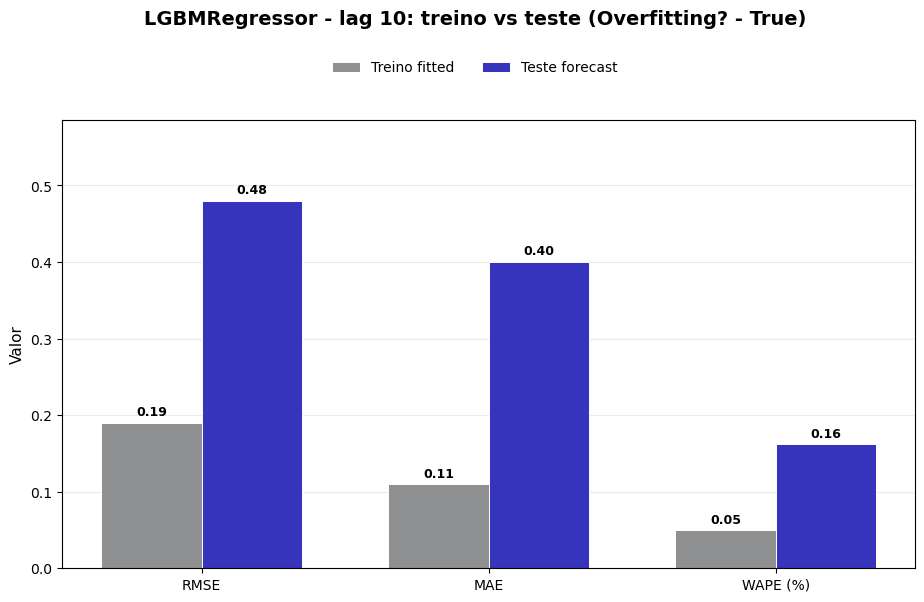

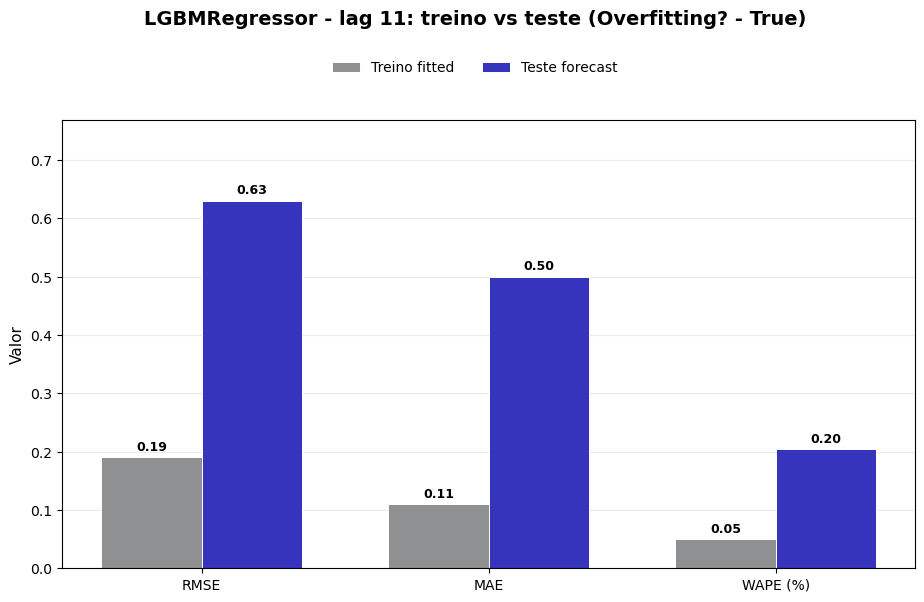

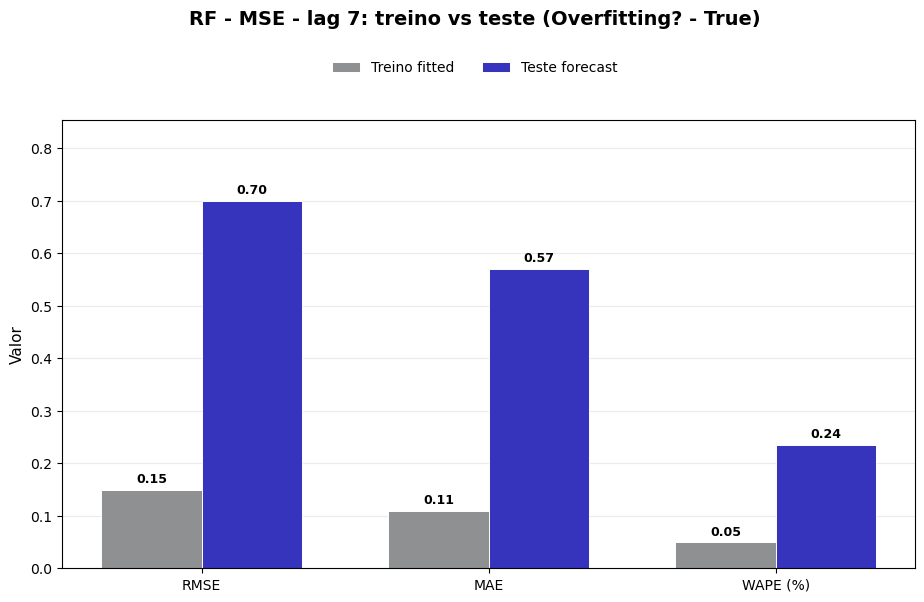

In [24]:
def plot_top_lag_model_metrics(lag_performance_ranked_df):
    top5_models = lag_performance_ranked_df.head(3).copy()

    metric_labels = ["RMSE", "MAE", "WAPE (%)"]
    train_cols = ["train_rmse", "train_mae", "train_wape"]
    test_cols = ["test_rmse", "test_mae", "test_wape"]

    for _, row in top5_models.iterrows():
        model_name = row["model"]
        lag = row["lag"]
        overfitting = row["Overfitting?"]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(11, 6.5))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="Treino fitted",
            color=colors["Treino"],
            edgecolor="white",
            linewidth=0.7,
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="Teste forecast",
            color=colors["Teste"],
            edgecolor="white",
            linewidth=0.7,
        )

        ymax = max(max(train_values), max(test_values))
        ax.set_ylim(0, ymax * 1.22)

        fig.suptitle(
            f"{model_name} - lag {lag}: treino vs teste (Overfitting? - {overfitting})",
            fontsize=14,
            fontweight="bold",
            y=0.97,
        )

        fig.legend(
            handles=[bars_train, bars_test],
            labels=["Treino fitted", "Teste forecast"],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.91),
            ncol=2,
            frameon=False,
        )

        ax.set_ylabel("Valor", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bars in [bars_train, bars_test]:
            labels = [f"{bar.get_height():.2f}" for bar in bars]
            ax.bar_label(
                bars,
                labels=labels,
                padding=3,
                fontsize=9,
                fontweight="bold",
            )

        fig.subplots_adjust(top=0.80)
        plt.show()


plot_top_lag_model_metrics(lag_performance_df_theoretical)



In [25]:
print(f"Best Theoretical Model by increasing the lags number: {lag_performance_df_theoretical.loc[0, 'model']} with lag {lag_performance_df_theoretical.loc[0, 'lag']} and Overfitting? - {lag_performance_df_theoretical.loc[0, 'Overfitting?']}")
print(f"Best Computational Model by increasing the lags number: {lag_performance_df_computacional.loc[0, 'model']} with lag {lag_performance_df_computacional.loc[0, 'lag']} and Overfitting? - {lag_performance_df_computacional.loc[0, 'Overfitting?']}") 

Best Theoretical Model by increasing the lags number: LGBMRegressor with lag 10 and Overfitting? - True
Best Computational Model by increasing the lags number: Ridge with lag 12 and Overfitting? - True


---

## **Feature Importance of the Selected Theoretical Model**

In [26]:
def get_lag_xy(lag, include_target_lag=True, get_features_selected=False):
    lags = []
    for key, values in var_lags.items():
        if key in THEORETICAL_VARIABLES:
            for v in values:
                if v <= lag:
                    lags.append(f"{key}_lag_{v}")

    target_lags = ["inflation_target_lag_1"] if include_target_lag else []
    feature_cols = THEORETICAL_VARIABLES + lags + target_lags
    model_cols = [TARGET_COL] + feature_cols

    train_data = df_train[model_cols].dropna().copy()
    test_data = df_test[model_cols].dropna().copy()

    X_train = train_data[feature_cols]
    y_train = train_data[TARGET_COL]

    X_test = test_data[feature_cols]
    y_test = test_data[TARGET_COL]

    if get_features_selected:
        return X_train, y_train, X_test, y_test, feature_cols
    else:
        return X_train, y_train, X_test, y_test


**LGBM Model**

Train RMSE: 0.19
Train MAE: 0.11
Train WAPE (%): 0.04937
Test RMSE: 0.48
Test MAE: 0.4
Test WAPE (%): 0.16222


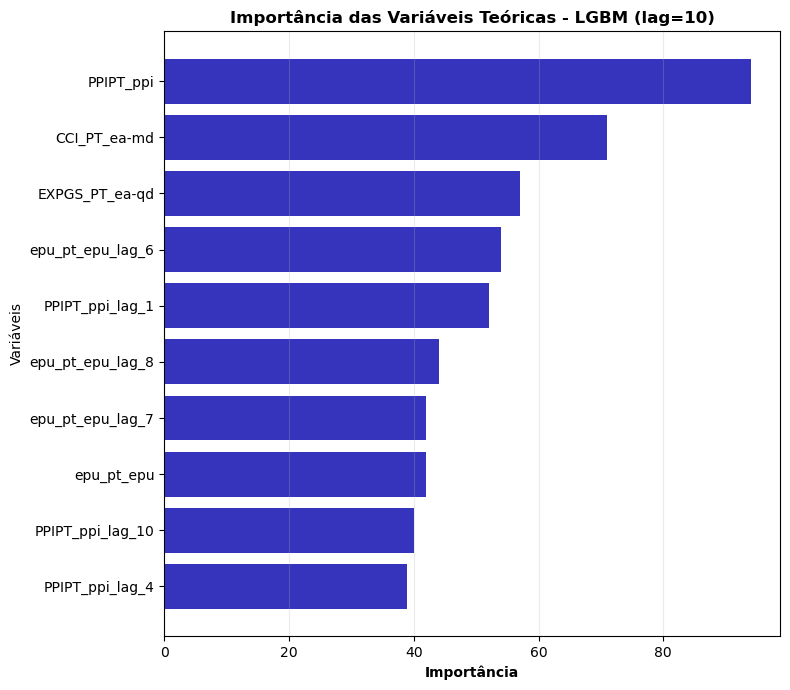

In [27]:
X_train, y_train, X_test, y_test, feature_cols = get_lag_xy(
    lag=10,
    include_target_lag=False,
    get_features_selected=True,
)

lgbm = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred_train = lgbm.predict(X_train)
y_pred_test = lgbm.predict(X_test)

train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train WAPE (%):", train_wape)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test WAPE (%):", test_wape)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm.feature_importances_,
})

importance_plot_df = (
    importance_df.sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(8, 7))
plt.barh(
    importance_plot_df["feature"],
    importance_plot_df["importance"],
    color=colors["Teste"],
)

plt.title("Importância das Variáveis Teóricas - LGBM (lag=10)", fontsize=12, fontweight="bold")
plt.xlabel("Importância", fontsize=10, fontweight="bold")
plt.ylabel("Variáveis")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()



---

## **Most Important Variables (Theoretical + Computational)**

In [28]:
BEST_FEATURES = [
    "PPIPT_ppi",
    "CCI_PT_ea-md",
    "EXPGS_PT_ea-qd",
    "epu_pt_epu_lag_6",
    "PPIPT_ppi_lag_1",
    "HICPNG_PT_ea-md",
   "HICPOV_PT_ea-md",
    "HICPNEF_PT_ea-md",
    "HICPSV_PT_ea-md_lag_12",
    "HICPNEF_PT_ea-md_lag_12",
    "HICPOV_PT_ea-md_lag_12",
    "HICPNG_PT_ea-md_lag_12",
    "inflation_target_lag_1",
    "PCEPI_fred-md",
]

In [29]:
from sklearn.base import clone

model_cols = [TARGET_COL] + BEST_FEATURES

train_best_data = df_train[model_cols].dropna().copy()
test_best_data = df_test[model_cols].dropna().copy()

common_dates = train_best_data.index.intersection(test_best_data.index)
test_best_data = test_best_data.drop(index=common_dates)

X_train = train_best_data[BEST_FEATURES]
y_train = train_best_data[TARGET_COL]

X_test = test_best_data[BEST_FEATURES]
y_test = test_best_data[TARGET_COL]

print(f"Treino: {X_train.index.min().date()} -> {X_train.index.max().date()} | {len(X_train)} obs")
print(f"Teste:  {X_test.index.min().date()} -> {X_test.index.max().date()} | {len(X_test)} obs")


Treino: 2001-01-01 -> 2023-06-01 | 270 obs
Teste:  2023-07-01 -> 2025-10-01 | 28 obs


In [30]:
results = []
predictions = {}

for model_name, model in models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred_train = fitted_model.predict(X_train)
    y_pred_test = fitted_model.predict(X_test)

    train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
    test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

    results.append({
        "model": model_name,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_wape": train_wape,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_wape": test_wape,
        "rmse_increase_pct": relative_error_increase_pct(train_rmse, test_rmse),
        "mae_increase_pct": relative_error_increase_pct(train_mae, test_mae),
        "wape_increase_pct": relative_error_increase_pct(train_wape, test_wape),
        "Overfitting?": has_overfitting(
            [train_rmse, train_mae, train_wape],
            [test_rmse, test_mae, test_wape],
        ),
    })

    predictions[model_name] = pd.DataFrame(
        {"y_true": y_test, "y_pred": y_pred_test},
        index=y_test.index,
    )

best_features_metrics_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
best_features_metrics_df = rank_models_by_average_test_rank(best_features_metrics_df)
display(best_features_metrics_df)


,model,train_rmse,train_mae,train_wape,test_rmse,test_mae,test_wape,rmse_increase_pct,mae_increase_pct,wape_increase_pct,Overfitting?,rank_test_rmse,rank_test_mae,rank_test_wape,rank_medio
0,Ridge,0.26,0.20,0.08844,0.36,0.31,0.12630,38.462,55.000,42.809,True,1.0,1.0,1.0,1.0
1,LGBMRegressor,0.22,0.14,0.06394,0.62,0.51,0.20788,181.818,264.286,225.117,True,2.0,2.0,2.0,2.0
2,RF - MAE,0.14,0.10,0.04597,1.55,1.44,0.59089,1007.143,1340.000,1185.382,True,3.0,3.0,3.0,3.0
3,RF - MSE,0.14,0.10,0.04610,2.24,2.06,0.84567,1500.000,1960.000,1734.425,True,4.0,4.0,4.0,4.0


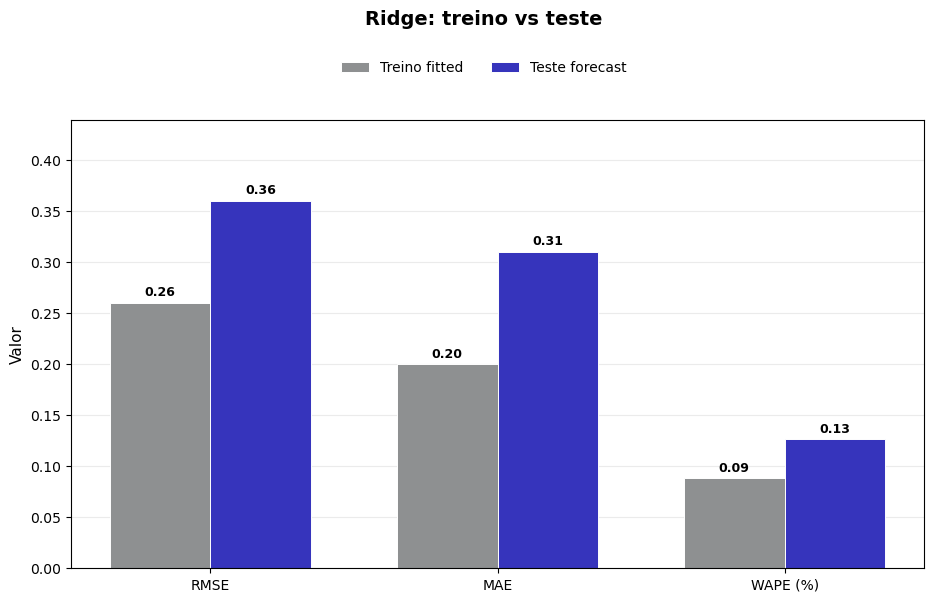

In [31]:
def plot_top_best_model_metrics(best_features_metrics_df, top_n=1):
    top_models = best_features_metrics_df.sort_values("test_rmse").head(top_n).copy()

    metric_labels = ["RMSE", "MAE", "WAPE (%)"]
    train_cols = ["train_rmse", "train_mae", "train_wape"]
    test_cols = ["test_rmse", "test_mae", "test_wape"]

    for _, row in top_models.iterrows():
        model_name = row["model"]
        overfitting = row["Overfitting?"]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(11, 6.5))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="Treino fitted",
            color=colors["Treino"],
            edgecolor="white",
            linewidth=0.7,
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="Teste forecast",
            color=colors["Teste"],
            edgecolor="white",
            linewidth=0.7,
        )

        ymax = max(max(train_values), max(test_values))
        ax.set_ylim(0, ymax * 1.22)

        fig.suptitle(
            f"{model_name}: treino vs teste",
            fontsize=14,
            fontweight="bold",
            y=0.97,
        )

        fig.legend(
            handles=[bars_train, bars_test],
            labels=["Treino fitted", "Teste forecast"],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.91),
            ncol=2,
            frameon=False,
        )

        ax.set_ylabel("Valor", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bars in [bars_train, bars_test]:
            labels = [f"{bar.get_height():.2f}" for bar in bars]
            ax.bar_label(
                bars,
                labels=labels,
                padding=3,
                fontsize=9,
                fontweight="bold",
            )

        fig.subplots_adjust(top=0.80)
        plt.show()


plot_top_best_model_metrics(best_features_metrics_df, top_n=1)



---

## **Optimizing the Best Model Achieved (Best Features)**

In [32]:
X_train = train_best_data[BEST_FEATURES]
y_train = train_best_data[TARGET_COL]

# Split temporal dentro do treino
split_idx = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-2, 10.0, log=True)

    model = Ridge(
        alpha=alpha,
        fit_intercept=True,
        random_state=RANDOM_STATE,
    )
    model.fit(X_tr, y_tr)

    y_pred_val = model.predict(X_val)
    val_rmse, val_mae, val_wape = regression_metrics(y_val, y_pred_val)

    trial.set_user_attr("val_rmse", val_rmse)
    trial.set_user_attr("val_mae", val_mae)
    return val_wape

study_best_features = optuna.create_study(direction="minimize")
study_best_features.optimize(objective, n_trials=1000, show_progress_bar=False)

print("Best params:", study_best_features.best_params)
print("Best validation WAPE (%):", study_best_features.best_value)
print("Best validation RMSE:", study_best_features.best_trial.user_attrs["val_rmse"])
print("Best validation MAE:", study_best_features.best_trial.user_attrs["val_mae"])

best_ridge = Ridge(
    alpha=study_best_features.best_params["alpha"],
    fit_intercept=True,
    random_state=RANDOM_STATE,
)
best_ridge.fit(X_train, y_train)

y_pred_train = best_ridge.predict(X_train)
y_pred_test = best_ridge.predict(X_test)

train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train WAPE (%):", train_wape)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test WAPE (%):", test_wape)
print("Overfitting?", has_overfitting(
    [train_rmse, train_mae, train_wape],
    [test_rmse, test_mae, test_wape]
))



[I 2026-06-02 18:14:18,313] A new study created in memory with name: no-name-5738e3d7-072b-4298-965f-616c6f273217
[I 2026-06-02 18:14:18,332] Trial 0 finished with value: 0.09243 and parameters: {'alpha': 0.08230488567587937}. Best is trial 0 with value: 0.09243.
[I 2026-06-02 18:14:18,342] Trial 1 finished with value: 0.09776 and parameters: {'alpha': 0.03511104597486872}. Best is trial 0 with value: 0.09243.
[I 2026-06-02 18:14:18,350] Trial 2 finished with value: 0.12748 and parameters: {'alpha': 1.6674717691654102}. Best is trial 0 with value: 0.09243.
[I 2026-06-02 18:14:18,360] Trial 3 finished with value: 0.12545 and parameters: {'alpha': 1.497485585664385}. Best is trial 0 with value: 0.09243.
[I 2026-06-02 18:14:18,368] Trial 4 finished with value: 0.10127 and parameters: {'alpha': 0.4074775062324519}. Best is trial 0 with value: 0.09243.
[I 2026-06-02 18:14:18,379] Trial 5 finished with value: 0.09374 and parameters: {'alpha': 0.06908896374584918}. Best is trial 0 with value:

Best params: {'alpha': 0.16498295007978878}
Best validation WAPE (%): 0.08956
Best validation RMSE: 0.33
Best validation MAE: 0.26
Train RMSE: 0.2
Train MAE: 0.15
Train WAPE (%): 0.06926
Test RMSE: 0.49
Test MAE: 0.4
Test WAPE (%): 0.16267
Overfitting? True


# **Implementing the Best Model (Best Features) with the Best Parameters**

In [33]:
BEST_ALPHA = study_best_features.best_params["alpha"] if "study_best_features" in globals() else 0.2097820888688671 # valor obtido na ultima execução

best_ridge = Ridge(
    alpha=BEST_ALPHA,
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

best_ridge.fit(X_train, y_train)

y_pred_train = best_ridge.predict(X_train)
y_pred_test = best_ridge.predict(X_test)

train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train WAPE (%):", train_wape)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test WAPE (%):", test_wape)
print("Overfitting?", has_overfitting(
    [train_rmse, train_mae, train_wape],
    [test_rmse, test_mae, test_wape]
))

coef_df = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente": best_ridge.coef_,
    "abs_coef": abs(best_ridge.coef_),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("\nIntercepto:")
print(best_ridge.intercept_)

print("\nCoeficientes ordenados por impacto absoluto:")
display(coef_df[["variavel", "coeficiente"]])

Train RMSE: 0.2
Train MAE: 0.15
Train WAPE (%): 0.06926
Test RMSE: 0.49
Test MAE: 0.4
Test WAPE (%): 0.16267
Overfitting? True

Intercepto:
0.12614229586603898

Coeficientes ordenados por impacto absoluto:


,variavel,coeficiente
0,HICPOV_PT_ea-md_lag_12,-3.362492
1,HICPOV_PT_ea-md,2.556715
2,HICPNEF_PT_ea-md_lag_12,-1.524355
3,HICPNEF_PT_ea-md,1.251009
4,HICPNG_PT_ea-md_lag_12,-0.830851
5,HICPNG_PT_ea-md,0.823211
6,HICPSV_PT_ea-md_lag_12,0.629916
7,inflation_target_lag_1,0.501852
8,PCEPI_fred-md,0.257933
9,CCI_PT_ea-md,-0.089843


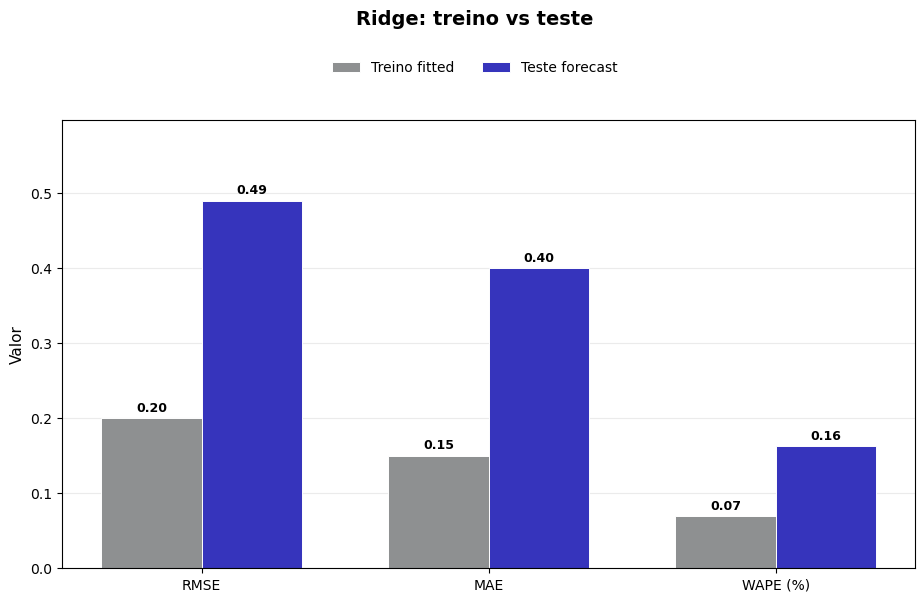

In [34]:
optimized_ridge_metrics_df = pd.DataFrame([{
    "model": "Ridge",
    "train_rmse": train_rmse,
    "train_mae": train_mae,
    "train_wape": train_wape,
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_wape": test_wape,
    "Overfitting?": has_overfitting(
        [train_rmse, train_mae, train_wape],
        [test_rmse, test_mae, test_wape]
    )
}])

plot_top_best_model_metrics(optimized_ridge_metrics_df, top_n=1)

In [35]:
import pandas as pd
import plotly.graph_objects as go

# Séries com índice temporal
fitted_train = pd.Series(y_pred_train, index=y_train.index, name="Ridge - Fitted Train")
forecast_test = pd.Series(y_pred_test, index=y_test.index, name="Ridge - Forecast Test")

fig = go.Figure()

# Valores reais no treino
fig.add_trace(go.Scatter(
    x=y_train.index,
    y=y_train,
    mode="lines",
    name="Real Train",
    line=dict(color="#8E9091", width=2)
))

# Fitted values no treino
fig.add_trace(go.Scatter(
    x=fitted_train.index,
    y=fitted_train,
    mode="lines",
    name="Ridge Fitted Train",
    line=dict(color="#3634bc", width=2)
))

# Valores reais no teste
fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test,
    mode="lines",
    name="Real Test",
    line=dict(color="#b0b0b0", width=2, dash="dot")
))

# Previsão no teste
fig.add_trace(go.Scatter(
    x=forecast_test.index,
    y=forecast_test,
    mode="lines",
    name="Ridge Forecast Test",
    line=dict(color="#d62728", width=2)
))

fig.update_layout(
    title="Ridge: Fitted Values no Treino e Previsão no Teste",
    xaxis_title="Data",
    yaxis_title="Inflation Target",
    template="plotly_white",
    font=dict(family="Times New Roman", size=12),
    height=550,
    hovermode="x unified"
)

fig.show()

---

## **Optimizing the Best Model Achieved (Theoretical Features)**

In [36]:
import optuna
from lightgbm import LGBMRegressor
from lightgbm.callback import early_stopping

# Mesmo dataset do modelo teórico com lag=10
X_train, y_train, X_test, y_test = get_lag_xy(
    lag=10,
    include_target_lag=False,   # manter igual ao bloco onde o LGBM lag=10 foi testado
)

# Split temporal dentro do treino
split_idx = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": RANDOM_STATE,
        "verbose": -1,
    }

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="l2",
        callbacks=[early_stopping(50, verbose=False)],
    )

    y_pred_val = model.predict(X_val)
    val_rmse, val_mae, val_wape = regression_metrics(y_val, y_pred_val)

    trial.set_user_attr("val_rmse", val_rmse)
    trial.set_user_attr("val_mae", val_mae)
    trial.set_user_attr("best_iteration", model.best_iteration_)
    return val_wape

study_theoretical = optuna.create_study(direction="minimize")
study_theoretical.optimize(objective, n_trials=1000, show_progress_bar=False)

print("Best params:", study_theoretical.best_params)
print("Best validation WAPE (%):", study_theoretical.best_value)
print("Best validation RMSE:", study_theoretical.best_trial.user_attrs["val_rmse"])
print("Best validation MAE:", study_theoretical.best_trial.user_attrs["val_mae"])
print("Best iteration:", study_theoretical.best_trial.user_attrs["best_iteration"])

best_params = study_theoretical.best_params.copy()
best_params.update({
    "random_state": RANDOM_STATE,
    "verbose": -1,
})

best_lgbm = LGBMRegressor(**best_params)
best_lgbm.fit(X_train, y_train)

y_pred_train = best_lgbm.predict(X_train)
y_pred_test = best_lgbm.predict(X_test)

train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train WAPE (%):", train_wape)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test WAPE (%):", test_wape)
print("Overfitting?", has_overfitting(
    [train_rmse, train_mae, train_wape],
    [test_rmse, test_mae, test_wape]
))

[I 2026-06-02 18:14:40,699] A new study created in memory with name: no-name-9d114177-985b-4836-8861-a96128a6039f
[I 2026-06-02 18:14:40,802] Trial 0 finished with value: 0.7249 and parameters: {'n_estimators': 290, 'learning_rate': 0.04913772434790187, 'num_leaves': 49, 'max_depth': 7, 'min_child_samples': 40, 'subsample': 0.7148711979724351, 'colsample_bytree': 0.7549856724025714, 'reg_alpha': 1.1646764813877815, 'reg_lambda': 0.17141502091680444}. Best is trial 0 with value: 0.7249.
[I 2026-06-02 18:14:40,956] Trial 1 finished with value: 0.73815 and parameters: {'n_estimators': 391, 'learning_rate': 0.012090154870543286, 'num_leaves': 23, 'max_depth': 12, 'min_child_samples': 40, 'subsample': 0.9536274342750868, 'colsample_bytree': 0.8554008062704977, 'reg_alpha': 0.004149391440151673, 'reg_lambda': 0.05430151577126016}. Best is trial 0 with value: 0.7249.
[I 2026-06-02 18:14:41,076] Trial 2 finished with value: 0.72726 and parameters: {'n_estimators': 1001, 'learning_rate': 0.0984

Best params: {'n_estimators': 834, 'learning_rate': 0.053974177006990504, 'num_leaves': 27, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.6198498585936856, 'colsample_bytree': 0.9711650206128551, 'reg_alpha': 0.09108967488740514, 'reg_lambda': 0.015360884571657471}
Best validation WAPE (%): 0.65476
Best validation RMSE: 3.01
Best validation MAE: 1.84
Best iteration: 513
Train RMSE: 0.08
Train MAE: 0.06
Train WAPE (%): 0.02613
Test RMSE: 0.61
Test MAE: 0.42
Test WAPE (%): 0.17255
Overfitting? True


# **Implementing the Best Model (Theoretical Features) with the Best Parameters**

In [37]:
BEST_LGBM_PARAMS = study_theoretical.best_params if "study_theoretical" in globals() else {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 6,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
}

best_lgbm = LGBMRegressor(
    **BEST_LGBM_PARAMS,
    random_state=RANDOM_STATE,
    verbose=-1,
)

best_lgbm.fit(X_train, y_train)

y_pred_train = best_lgbm.predict(X_train)
y_pred_test = best_lgbm.predict(X_test)

train_rmse, train_mae, train_wape = regression_metrics(y_train, y_pred_train)
test_rmse, test_mae, test_wape = regression_metrics(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train WAPE (%):", train_wape)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test WAPE (%):", test_wape)
print("Overfitting?", has_overfitting(
    [train_rmse, train_mae, train_wape],
    [test_rmse, test_mae, test_wape]
))

importance_df = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": best_lgbm.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

print("\nMelhores hiperparâmetros:")
print(BEST_LGBM_PARAMS)

print("\nImportância das variáveis:")
display(importance_df)

Train RMSE: 0.08
Train MAE: 0.06
Train WAPE (%): 0.02613
Test RMSE: 0.61
Test MAE: 0.42
Test WAPE (%): 0.17255
Overfitting? True

Melhores hiperparâmetros:
{'n_estimators': 834, 'learning_rate': 0.053974177006990504, 'num_leaves': 27, 'max_depth': 3, 'min_child_samples': 18, 'subsample': 0.6198498585936856, 'colsample_bytree': 0.9711650206128551, 'reg_alpha': 0.09108967488740514, 'reg_lambda': 0.015360884571657471}

Importância das variáveis:


,variavel,importancia
0,epu_pt_epu_lag_7,227
1,PPIPT_ppi_lag_4,214
2,CCI_PT_ea-md,214
3,epu_pt_epu_lag_6,199
4,epu_pt_epu_lag_8,198
5,PPIPT_ppi,198
6,PPIPT_ppi_lag_6,174
7,UNETOT_PT_ea-md,173
8,epu_pt_epu,169
9,PPIPT_ppi_lag_1,162


---

## **Ploting models**

In [38]:
from sklearn.base import clone
import plotly.graph_objects as go
from IPython.display import HTML, display

def build_model(variables, models=models):
    scores_train = {}
    scores_test = {}
    predictions_test = {}

    model_cols = [TARGET_COL] + variables
    train_data = df_train[model_cols].dropna().copy()
    test_data = df_test[model_cols].dropna().copy()

    common_dates = train_data.index.intersection(test_data.index)
    test_data = test_data.drop(index=common_dates)

    X_train = train_data[variables]
    y_train = train_data[TARGET_COL]

    X_test = test_data[variables]
    y_test = test_data[TARGET_COL]

    for model_name, clf in models.items():
        fitted_model = clone(clf)
        fitted_model.fit(X_train, y_train)

        pred_train = fitted_model.predict(X_train)
        pred_test = fitted_model.predict(X_test)

        scores_train[model_name] = regression_metrics(y_train, pred_train)
        scores_test[model_name] = regression_metrics(y_test, pred_test)
        predictions_test[model_name] = pred_test

    return scores_train, scores_test, predictions_test, models


def plot_predictions(y_true, predictions, models_to_plot=None, title="Previsoes vs Valores Reais"):
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=y_true.index,
            y=y_true.values,
            mode="lines",
            name="Valores Reais",
            line=dict(color="#8E9091", width=2.5),
        )
    )

    if models_to_plot is None:
        models_to_plot = list(predictions.keys())

    for model_name in models_to_plot:
        line_color = "#1800ad" if len(models_to_plot) == 1 else None

        fig.add_trace(
            go.Scatter(
                x=y_true.index,
                y=predictions[model_name],
                mode="lines",
                name=model_name,
                line=dict(color=line_color, width=2),
            )
        )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(family="Times New Roman", size=14),
        ),
        xaxis_title="Data",
        yaxis_title="Valor",
        template="plotly_white",
        hovermode="x unified",
        height=560,
        margin=dict(l=50, r=30, t=90, b=80),
        font=dict(family="Times New Roman", size=12),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5,
            font=dict(family="Times New Roman", size=12),
        ),
    )

    fig.update_xaxes(
        tickangle=-35,
        title_font=dict(family="Times New Roman", size=14),
        tickfont=dict(family="Times New Roman", size=12),
    )

    fig.update_yaxes(
        title_font=dict(family="Times New Roman", size=14),
        tickfont=dict(family="Times New Roman", size=12),
    )

    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

In [39]:
# 1) Em nível
train, test, preds, _ = build_model(THEORETICAL_VARIABLES)
best_model_level = theoretical_metrics_df.iloc[0]["model"]

print(f"Best model in level: {best_model_level}")
plot_predictions(
    df_test[TARGET_COL],
    preds,
    models_to_plot=[best_model_level],
    title=f"Best model in level (Theoretical Features): {best_model_level}",
)

# 2) Desfasamento da variável alvo até lag 3

def performance_to_df(scores_train, scores_test):
    rows = []
    for model_name in scores_train.keys():
        rows.append({
            "model": model_name,
            "train_rmse": scores_train[model_name][0],
            "train_mae": scores_train[model_name][1],
            "train_wape": scores_train[model_name][2],
            "test_rmse": scores_test[model_name][0],
            "test_mae": scores_test[model_name][1],
            "test_wape": scores_test[model_name][2],
        })
    return pd.DataFrame(rows)


target_lags_1 = [f"{TARGET_COL}_lag_1"]
target_lags_2 = [f"{TARGET_COL}_lag_{i}" for i in range(1, 3)]
target_lags_3 = [f"{TARGET_COL}_lag_{i}" for i in range(1, 4)]

train1, test1, preds1, _ = build_model(target_lags_1)
train2, test2, preds2, _ = build_model(target_lags_2)
train3, test3, preds3, _ = build_model(target_lags_3)

perf1 = performance_to_df(train1, test1)
perf2 = performance_to_df(train2, test2)
perf3 = performance_to_df(train3, test3)

rank1 = rank_models_by_average_test_rank(perf1)
rank2 = rank_models_by_average_test_rank(perf2)
rank3 = rank_models_by_average_test_rank(perf3)

best_model_lag1 = rank1.iloc[0]["model"]
best_model_lag2 = rank2.iloc[0]["model"]
best_model_lag3 = rank3.iloc[0]["model"]

preds_target_lags = {
    f"Lag 1 ({best_model_lag1})": preds1[best_model_lag1],
    f"Lag 2 ({best_model_lag2})": preds2[best_model_lag2],
    f"Lag 3 ({best_model_lag3})": preds3[best_model_lag3],
}

print(f"Best model for lag 1: {best_model_lag1}")
print(f"Best model for lag 2: {best_model_lag2}")
print(f"Best model for lag 3: {best_model_lag3}")

plot_predictions(
    df_test[TARGET_COL],
    preds_target_lags,
    models_to_plot=[
        f"Lag 1 ({best_model_lag1})",
        f"Lag 2 ({best_model_lag2})",
        f"Lag 3 ({best_model_lag3})",
    ],
    title="Valores reais vs previsões com lags até 3",
)


# 3) Melhor número de lags teóricas vs melhor número de lags computacionais


best_lag_theoretical = int(lag_performance_df_theoretical.loc[0, "lag"])
best_model_theoretical = lag_performance_df_theoretical.loc[0, "model"]

lags_theoretical = [
    f"{key}_lag_{v}"
    for key, values in var_lags.items()
    if key in THEORETICAL_VARIABLES
    for v in values
    if v <= best_lag_theoretical
]

X_train_theoretical = df_train[THEORETICAL_VARIABLES + lags_theoretical].dropna()
y_train_theoretical = df_train[TARGET_COL].iloc[best_lag_theoretical:]

X_test_theoretical = df_test[THEORETICAL_VARIABLES + lags_theoretical]
pred_theoretical = clone(models[best_model_theoretical]).fit(
    X_train_theoretical, y_train_theoretical
).predict(X_test_theoretical)


best_lag_computacional = int(lag_performance_df_computacional.loc[0, "lag"])
best_model_computacional = lag_performance_df_computacional.loc[0, "model"]

lags_computacional = [
    f"{key}_lag_{v}"
    for key, values in var_lags.items()
    if key in COMPUTACIONAL_VARIABLES
    for v in values
    if v <= best_lag_computacional
]

target_lags = ["inflation_target_lag_1"]

X_train_computacional = df_train[COMPUTACIONAL_VARIABLES + lags_computacional + target_lags].dropna()
y_train_computacional = df_train[TARGET_COL].iloc[best_lag_computacional:]

X_test_computacional = df_test[COMPUTACIONAL_VARIABLES + lags_computacional + target_lags]
pred_computacional = clone(models[best_model_computacional]).fit(
    X_train_computacional, y_train_computacional
).predict(X_test_computacional)


plot_predictions(
    df_test[TARGET_COL],
    {
        f"Teóricas | {best_model_theoretical} | lag {best_lag_theoretical}": pred_theoretical,
        f"Computacionais | {best_model_computacional} | lag {best_lag_computacional}": pred_computacional,
    },
    title="Valores reais vs melhor modelo teórico e melhor modelo computacional",
)

# 4) Best features

model_cols = [TARGET_COL] + BEST_FEATURES

train_best_data = df_train[model_cols].dropna().copy()
test_best_data = df_test[model_cols].dropna().copy()

common_dates = train_best_data.index.intersection(test_best_data.index)
test_best_data = test_best_data.drop(index=common_dates)

X_train = train_best_data[BEST_FEATURES]
y_train = train_best_data[TARGET_COL]

X_test = test_best_data[BEST_FEATURES]
y_test_local = test_best_data[TARGET_COL]

best_alpha = study_best_features.best_params["alpha"] if "study_best_features" in globals() else BEST_ALPHA

best_model_tuned = Ridge(
    alpha=best_alpha,
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

best_model_tuned.fit(X_train, y_train)
y_pred_tuned = best_model_tuned.predict(X_test)

preds_tuned = {
    f"Ridge Tuned": y_pred_tuned
}

plot_predictions(
    y_true=y_test_local,
    predictions=preds_tuned,
    models_to_plot=list(preds_tuned.keys()),
    title=f"Melhor Modelo (Feature Importance): Ridge",
)


train, test, preds, _ = build_model(BEST_FEATURES)

all_models = list(best_features_metrics_df["model"])

plot_predictions(
    df_test[TARGET_COL],
    preds,
    models_to_plot=all_models,
    title="Comparação de todos os modelos com as melhores features",
)


Best model in level: Ridge


Best model for lag 1: Ridge
Best model for lag 2: RF - MAE
Best model for lag 3: RF - MAE
